<a href="https://colab.research.google.com/github/Mehhhhull/placement-project-logistic-regression/blob/main/ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
import numpy as np
import pandas as pd

In [150]:
df=pd.read_csv('/content/modified_placement_data.csv')

In [151]:
df['cgpa'] = df['cgpa'].str.replace(',', '.', regex=False).astype(float)
df.head()

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


In [152]:
df.shape


(100, 3)

In [153]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [154]:
import matplotlib.pyplot as plt


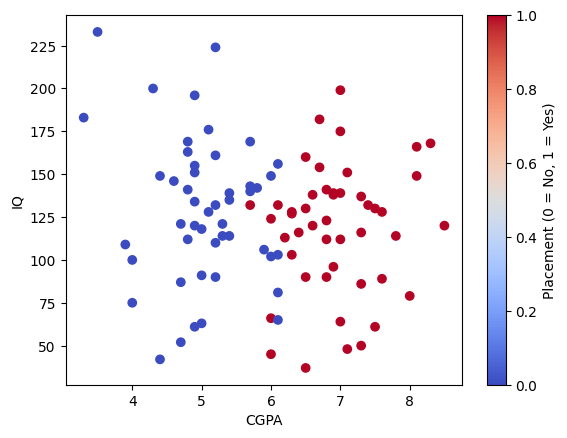

In [155]:

plt.scatter(df['cgpa'], df['iq'], c=df['placement'].map({'Yes': 1, 'No': 0}), cmap='coolwarm')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.colorbar(label='Placement (0 = No, 1 = Yes)')
plt.show()

In [156]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

# Handle NaN values: Drop rows where any feature in x is NaN
nan_mask = x.isnull().any(axis=1)
x = x[~nan_mask]
y = y[~nan_mask]

# Convert 'Yes'/'No' labels to 1/0 for numerical compatibility
y = y.map({'No': 0, 'Yes': 1})

In [157]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [158]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [159]:
from sklearn.model_selection import train_test_split

In [160]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [161]:
x_train

,cgpa,iq
69,8.5,120.0
4,5.8,142.0
70,6.3,127.0
58,8.0,79.0
7,5.0,63.0
...,...,...
17,3.3,183.0
87,5.7,132.0
78,6.1,81.0
68,4.0,75.0


In [162]:
y_test

,placement
99,1
51,0
19,0
1,0
25,0
79,1
53,1
43,1
39,0
31,0


In [163]:
from sklearn.preprocessing import StandardScaler

In [164]:
scaler=StandardScaler()

In [165]:
x_train=scaler.fit_transform(x_train)


In [166]:
x_train

array([[ 2.1784975 , -0.08058331],
       [-0.19325381,  0.45189297],
       [ 0.24595939,  0.08884096],
       [ 1.73928429, -1.07292547],
       [-0.89599494, -1.46018095],
       [ 1.38791373, -0.8308908 ],
       [ 1.30007109, -1.50858789],
       [ 0.59732996,  1.42003167],
       [ 0.86085788,  1.83149062],
       [-1.07168022, -0.27421105],
       [-0.72030966, -0.80668733],
       [-0.28109645,  0.40348604],
       [-0.28109645,  1.10538659],
       [ 1.1243858 ,  0.33087564],
       [ 0.77301524,  0.3550791 ],
       [ 1.1243858 , -1.77482603],
       [-1.07168022,  0.96016579],
       [ 0.07027411, -1.41177402],
       [-0.72030966,  2.4365773 ],
       [ 0.42164468,  0.16145136],
       [ 1.56359901, -0.22580411],
       [-1.15952286, -0.87929773],
       [-0.72030966,  0.91175885],
       [-1.07168022,  1.10538659],
       [-1.42305078,  0.62131725],
       [ 0.6851726 , -0.00797291],
       [ 1.1243858 , -0.17739718],
       [ 1.1243858 , -0.9035012 ],
       [ 1.21222845,

In [167]:
x_test=scaler.transform(x_test)

In [168]:
x_test

array([[ 0.15811675, -0.25000758],
       [-1.07168022,  0.42768951],
       [-0.72030966,  0.2098583 ],
       [-0.10541117, -0.41943185],
       [-0.89599494, -0.78248386],
       [ 0.42164468, -0.80668733],
       [ 2.00281221,  1.08118313],
       [ 0.6851726 ,  0.42768951],
       [-1.2473655 ,  0.54870684],
       [-1.86226399, -0.34682145]])

In [169]:
from sklearn.linear_model import LogisticRegression

In [170]:
clf=LogisticRegression()

In [171]:
#model training
clf.fit(x_train,y_train)

LogisticRegression()

In [172]:
y_pred=clf.predict(x_test)

In [173]:
y_test

,placement
99,1
51,0
19,0
1,0
25,0
79,1
53,1
43,1
39,0
31,0


In [174]:
from sklearn.metrics import accuracy_score

In [175]:
accuracy_score(y_test,y_pred)

1.0

In [176]:

from mlxtend.plotting import plot_decision_regions

<Axes: >

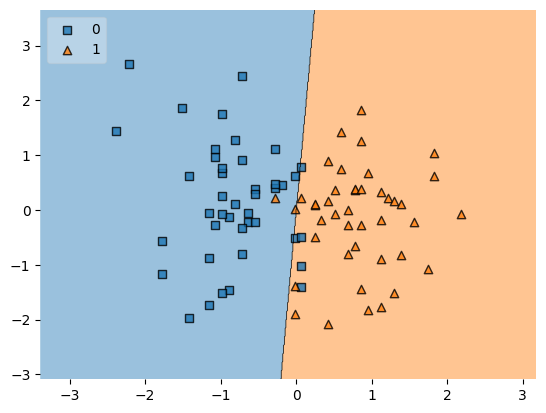

In [177]:

plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [178]:

import pickle


In [179]:

pickle.dump(clf,open('model.pkl','wb'))